In [1]:
import pyslfp as sl
import pygeoinf as inf
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

rng = np.random.default_rng(seed=42)

In [2]:
fingerprint = sl.FingerPrint(lmax=128)
fingerprint.set_state_from_ice_ng()

stations = [
    {"name": "Brest", "coord": (48.383, -4.5), "marker": "o"},          # Circle
    {"name": "Easter Island", "coord": (-27.15, -109.45), "marker": "s"}, # Square
    {"name": "Sydney", "coord": (-33.85, 151.233), "marker": "^"},      # Triangle
    {"name": "Vernadsky", "coord": (-65.25, -64.267), "marker": "D"}    # Diamond
]

points = [st["coord"] for st in stations]


lats = [lat for lat, _ in points]
lons = [lon for _, lon in points]


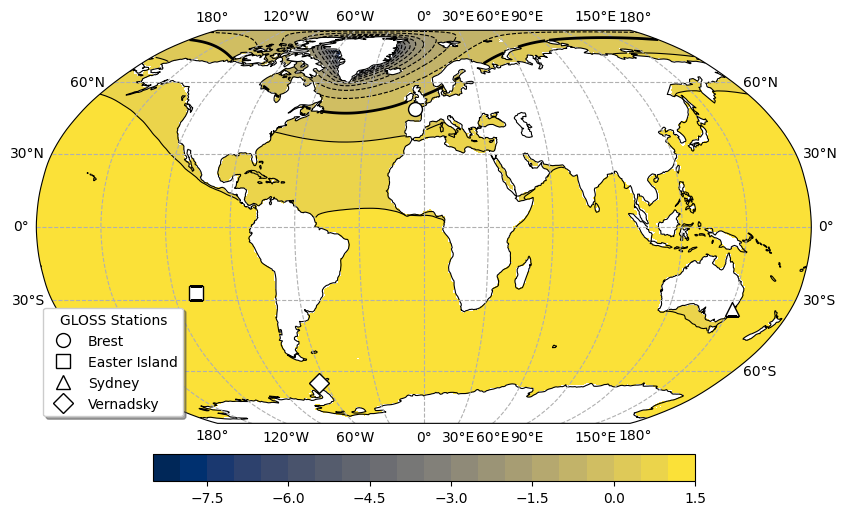

In [3]:
# Set a normalised load for Greenland
greenland_load = fingerprint.greenland_load()
greenland_gmsl = fingerprint.mean_sea_level_change(greenland_load)
greenland_load /= greenland_gmsl

# Compute and plot the fingerprint
greenland_fingerprint, _, _, _ = fingerprint(direct_load=greenland_load)

contour_levels = np.linspace(-8.5, 1.5, 21)
contour_kwargs = contour_lines_kwargs={
        'colors': 'black',
        'linewidths': 0.8,
        'linestyles': ['dashed' if l < 0 else 'solid' for l in contour_levels]
    }

fig, ax, im = sl.plot(greenland_fingerprint *fingerprint.ocean_projection(), 
        cmap="cividis", contour=True, 
        contour_lines=True,  
        levels=contour_levels, 
        contour_lines_kwargs=contour_kwargs
        )


ax.contour(
    greenland_fingerprint.lons(), 
    greenland_fingerprint.lats(), 
    (greenland_fingerprint * fingerprint.ocean_projection()).data,
    levels=[0], 
    colors='black', 
    linewidths=2, 
    transform=ccrs.PlateCarree()
)

for st in stations:
    lat, lon = st["coord"]
    ax.plot(
        lon, lat, 
        marker=st["marker"], 
        color="white",          # High contrast against cividis
        markeredgecolor="black", 
        markersize=10, 
        label=st["name"], 
        transform=ccrs.PlateCarree(),
        linestyle='None'        # Ensures no lines connect the points
    )

ax.legend(loc='lower left', title="GLOSS Stations", frameon=True, shadow=True)


plt.show()

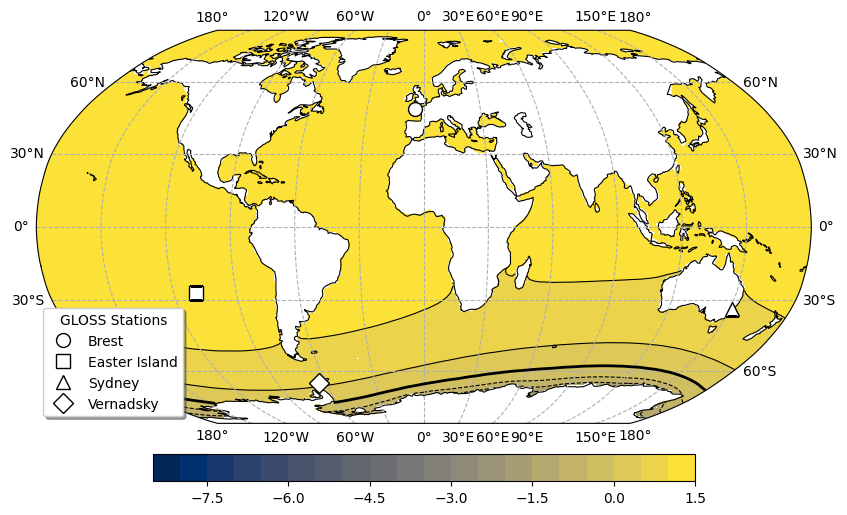

In [4]:
# Set a normalised load for east Antarctic
east_antarctic_load = fingerprint.east_antarctic_load()
east_antarctic_gmsl = fingerprint.mean_sea_level_change(east_antarctic_load)
east_antarctic_load /= east_antarctic_gmsl

# Compute and plot the fingerprint
east_antarctic_fingerprint, _, _, _ = fingerprint(direct_load=east_antarctic_load)
fig, ax, im, = sl.plot(east_antarctic_fingerprint *fingerprint.ocean_projection(), 
        cmap="cividis", contour=True, 
        contour_lines=True,  
        levels=contour_levels, 
        contour_lines_kwargs=contour_kwargs
        )


ax.contour(
    east_antarctic_fingerprint.lons(), 
    east_antarctic_fingerprint.lats(), 
    (east_antarctic_fingerprint * fingerprint.ocean_projection()).data,
    levels=[0], 
    colors='black', 
    linewidths=2, 
    transform=ccrs.PlateCarree()
)


for st in stations:
    lat, lon = st["coord"]
    ax.plot(
        lon, lat, 
        marker=st["marker"], 
        color="white",          # High contrast against cividis
        markeredgecolor="black", 
        markersize=10, 
        label=st["name"], 
        transform=ccrs.PlateCarree(),
        linestyle='None'        # Ensures no lines connect the points
    )

ax.legend(loc='lower left', title="GLOSS Stations", frameon=True, shadow=True)


plt.show()

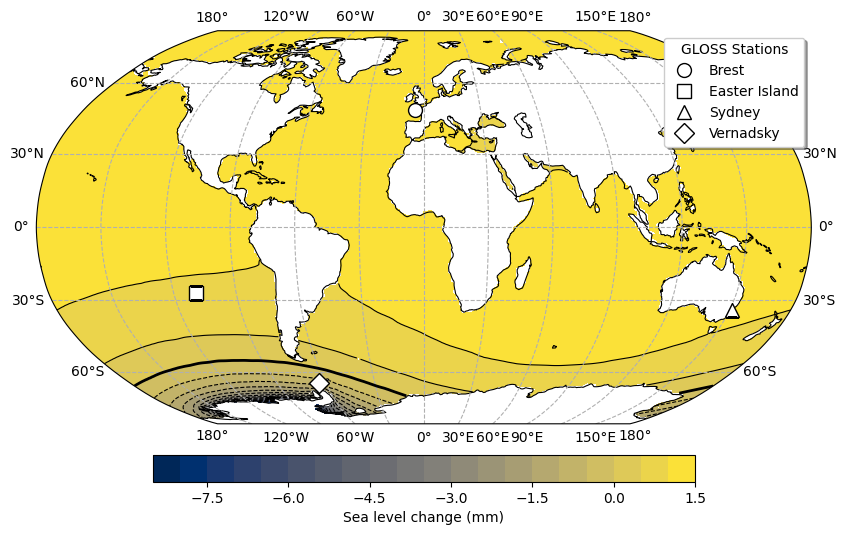

In [5]:
# Set a normalised load for east Antarctic
west_antarctic_load = fingerprint.west_antarctic_load()
west_antarctic_gmsl = fingerprint.mean_sea_level_change(west_antarctic_load)
west_antarctic_load /= west_antarctic_gmsl

# Compute and plot the fingerprint
west_antarctic_fingerprint, _, _, _ = fingerprint(direct_load=west_antarctic_load)
fig, ax, im = sl.plot(west_antarctic_fingerprint *fingerprint.ocean_projection(), 
        cmap="cividis", contour=True, 
        contour_lines=True,  
        levels=contour_levels, 
        contour_lines_kwargs=contour_kwargs,
        colorbar_label="Sea level change (mm)"
        )

ax.contour(
    west_antarctic_fingerprint.lons(), 
    west_antarctic_fingerprint.lats(), 
    (west_antarctic_fingerprint * fingerprint.ocean_projection()).data,
    levels=[0], 
    colors='black', 
    linewidths=2, 
    transform=ccrs.PlateCarree()
)

for st in stations:
    lat, lon = st["coord"]
    ax.plot(
        lon, lat, 
        marker=st["marker"], 
        color="white",          # High contrast against cividis
        markeredgecolor="black", 
        markersize=10, 
        label=st["name"], 
        transform=ccrs.PlateCarree(),
        linestyle='None'        # Ensures no lines connect the points
    )

ax.legend(loc='upper right', title="GLOSS Stations", frameon=True, shadow=True)


plt.savefig('west_antarctic.png', dpi=300, bbox_inches='tight')


plt.show()

In [6]:
# Set up the sea level operator
sea_level_operator = fingerprint.as_sobolev_linear_operator(2, 0.1 * fingerprint.mean_sea_floor_radius)

In [7]:
# Set up the model space, with the following ordering:
# 0 = Greenland
# 1 = West Antarctica
# 2 = East Antarctica 
model_space = inf.EuclideanSpace(3)
load_space = sea_level_operator.domain

# Set the basis vectors from which the operator will be formed
model_space_basis = [model_space.basis_vector(i) for i in range(model_space.dim)]
load_basis = [greenland_load, west_antarctic_load, east_antarctic_load]

# Set up the model to load operator
basis_pairs = [[model,load] for model, load in zip( load_basis, model_space_basis)]
model_to_load_operator = inf.LinearOperator.from_tensor_product(model_space, load_space, basis_pairs)

# Set the tide gauge points and operator
tide_gauge_operator = sl.tide_gauge_operator(sea_level_operator.codomain, points)

# Set the forward operator and print the resulting matrix
forward_operator = tide_gauge_operator @ sea_level_operator @ model_to_load_operator
#forward_matrix = forward_operator.matrix(dense=True)

data_space = forward_operator.codomain

# data the data error measure
data_error_measure = inf.GaussianMeasure.from_standard_deviations(data_space, np.array([0.01, 0.02, 0.01, 0.05]))
#data_error_measure = inf.GaussianMeasure.from_standard_deviation(data_space, 0.1)

# Set the forward problem
forward_problem = inf.LinearForwardProblem(forward_operator, data_error_measure=data_error_measure)


# Set the model prior measure
var_greenland = 0.2
var_west = 0.4
rho = 0.9  
amp_ratio = 1/3

# Calculate East parameters based on West
std_west = np.sqrt(var_west)
std_east = std_west * amp_ratio
var_east = std_east**2
covariance_we = rho * std_west * std_east

model_prior_covariance_matrix = np.array([
    [var_greenland, 0.0,           0.0          ],
    [0.0,           var_west,      covariance_we],
    [0.0,           covariance_we, var_east     ]
])


model_prior_measure = inf.GaussianMeasure.from_covariance_matrix(model_space, model_prior_covariance_matrix)

# get model and data
model, data = forward_problem.synthetic_model_and_data(model_prior_measure)



# Set up the inverse problem
least_squares_problem = inf.LinearLeastSquaresInversion(forward_problem)

least_squares_operator = least_squares_problem.least_squares_operator(0, inf.CholeskySolver())

least_squares_model = least_squares_operator(data)
least_squares_prediction = forward_operator(least_squares_model)

print(f'model          = {model}')
print(f'data           = {data}')
print(f'inverted model = {least_squares_model}')
print(f'predicted data = {least_squares_prediction}')



model          = [-0.78384284 -0.48218491 -0.19162051]
data           = [-0.88946714 -1.59832683 -1.45821449 -0.54003416]
inverted model = [-0.77938816 -0.5360499  -0.13714396]
predicted data = [-0.88873443 -1.60495387 -1.4569415  -0.5273497 ]


In [8]:
print(forward_problem.chi_squared(model, data))
print(forward_problem.chi_squared(least_squares_model, data))


4.837024823597884
0.19572616613835814


In [9]:
print(forward_operator)

[[ 0.19335882  1.0963292   1.09626046]
 [ 1.23058434  0.89533579  1.20974333]
 [ 0.98738455  1.05312801  0.89581072]
 [ 1.2597502  -0.99245919  0.56526886]]


In [10]:
trial_model = np.array([-0.1,  0.6596916,  0.2])
print(forward_problem.chi_squared(trial_model, data))

96057.92120596358


In [11]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

print(forward_operator.adjoint(weights))

[0.91779189 0.51320655 0.9417645 ]


In [22]:
lam = 0.5
A = forward_operator
C = data_error_measure.covariance
up = np.array([1, 1, 1])

N = A@A.adjoint + lam * C

Ni = inf.EigenSolver()(N)

vp = Ni(A(up))

print(vp)

print(A.adjoint(vp))

[ 0.04981068  0.37793911  0.55747305 -0.01996216]
[1.00005229 0.99999466 0.99991823]
